# Pitch your partition

Everyone in this room is a node. Each person is joined to their K nearest people. Your group makes **one** partition of these nodes and has three minutes to say why it is the one to use. There is no answer key.

Run *Setup*, then *The graph*, then go to your group's section.

In [10]:
#@title Setup. Press the play button. Nothing to type here. { display-mode: "form" }
try:
    import igraph
except ImportError:
    %pip install -q python-igraph
    import igraph

import inspect, io, json, os, pathlib, platform, subprocess, tarfile, tempfile, textwrap, urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEATS_URL = "https://raw.githubusercontent.com/skojaku/adv-net-sci/main/lecture-note/m05-clustering/pitch/seats.csv"
try:
    seats = pd.read_csv(SEATS_URL)
except Exception:
    seats = pd.read_csv(SEATS_URL.replace("seats.csv", "seats-example.csv"))
    print("#" * 70)
    print("REHEARSAL DATA: seats.csv is not published yet, so this is an invented room.")
    print("Run this notebook again once the lecturer says the seats are up.")
    print("#" * 70)

P = seats[["x", "y"]].to_numpy(dtype=float)
N = len(P)
DIST = np.linalg.norm(P[:, None, :] - P[None, :, :], axis=2)
np.fill_diagonal(DIST, np.inf)


def make_graph(k):
    """Join each person to their k nearest people. An edge is kept if either end chose it."""
    edges = sorted({tuple(sorted((i, int(j)))) for i in range(N) for j in np.argsort(DIST[i], kind="stable")[:k]})
    return edges, igraph.Graph(n=N, edges=edges)


PALETTE = ["#8FA8DC", "#E3877A", "#DAB167", "#B79AD6", "#9CCBE8", "#F0A8D0", "#C9A27E", "#BDB8AA", "#E5E5E5", "#F2D16B"]   # light enough for black labels


def show(labels):
    """Draw the partition with igraph (colour = group, dark edge = edge between groups)."""
    labels = np.array(labels)
    assert len(labels) == N, f"labels needs one number per node: {N} numbers, you gave {len(labels)}"
    names = np.unique(labels)
    colour = [PALETTE[int(np.where(names == g)[0][0]) % len(PALETTE)] for g in labels]
    cross = [labels[u] != labels[v] for u, v in graph.get_edgelist()]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    igraph.plot(graph, target=ax, layout=igraph.Layout(P.tolist()), bbox=None,
                vertex_color=colour, vertex_size=30, vertex_label=list(range(N)),
                vertex_label_color="#1A1A1A",
                edge_color=["#1A1A1A" if c else "#BDB8AA" for c in cross],
                edge_width=[1.2 if c else 2.5 for c in cross])
    plt.show()


GT = pathlib.Path(tempfile.gettempdir()) / "graph-tool"
GT_PYTHON = GT / "env" / "bin" / "python"


def graph_tool(fn):
    """Run the function fn inside graph-tool and return what it returns. In fn, `gt` is
    graph-tool and `g` is the network. graph-tool is not on PyPI, so the first call installs
    it from conda into a private folder (one to three minutes, only group 4 pays for it)."""
    if not GT_PYTHON.exists():
        kind = {"Linux": "linux-64",
                "Darwin": "osx-arm64" if platform.machine() == "arm64" else "osx-64"}.get(platform.system())
        if kind is None:
            raise SystemExit("graph-tool does not run on Windows. Open this notebook in Colab instead.")
        print("Installing graph-tool: one to three minutes. Please wait.")
        url = f"https://micro.mamba.pm/api/micromamba/{kind}/latest"
        tarfile.open(fileobj=io.BytesIO(urllib.request.urlopen(url).read()), mode="r:bz2").extract("bin/micromamba", GT)
        subprocess.run([GT / "bin" / "micromamba", "create", "-y", "-q", "-p", GT / "env", "-c", "conda-forge", "graph-tool"],
                       env={**os.environ, "MAMBA_ROOT_PREFIX": str(GT / "root")}, check=True)
    with tempfile.TemporaryDirectory() as tmp:
        tmp = pathlib.Path(tmp)
        (tmp / "in.json").write_text(json.dumps(dict(n=N, edges=EDGES)))
        (tmp / "run.py").write_text(
            "import json\nimport graph_tool.all as gt\n"
            "gt.seed_rng(1); gt.openmp_set_num_threads(1)\n"
            "d = json.load(open('in.json'))\n"
            "g = gt.Graph(directed=False); g.add_vertex(d['n']); g.add_edge_list(d['edges'])\n\n"
            + textwrap.dedent(inspect.getsource(fn))
            + f"\n\njson.dump({fn.__name__}(g), open('out.json', 'w'))\n")
        done = subprocess.run([GT_PYTHON, "run.py"], cwd=tmp, capture_output=True, text=True)
        if done.returncode:
            raise RuntimeError(done.stderr[-1500:])
        return json.loads((tmp / "out.json").read_text())


print(f"Ready. {N} people.")

Ready. 10 people.


## The graph
The data is where people sit; it is not a network. K decides which pairs become edges. Change it and run the cell again.

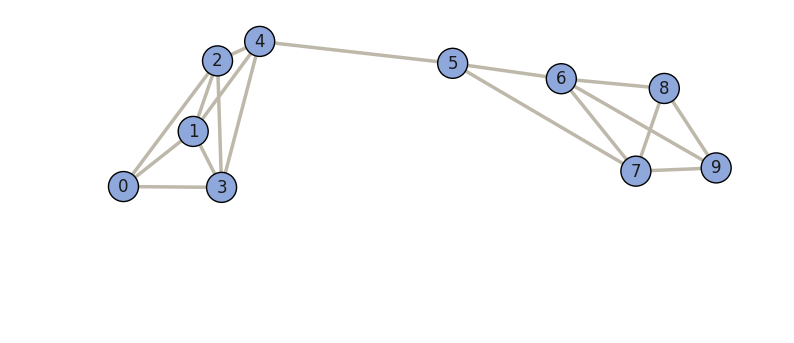

[[0 1 1 1 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0 0]
 [1 1 1 0 1 0 0 0 0 0]
 [0 1 1 1 0 1 0 0 0 0]
 [0 0 0 0 1 0 1 1 0 0]
 [0 0 0 0 0 1 0 1 1 1]
 [0 0 0 0 0 1 1 0 1 1]
 [0 0 0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 1 1 1 0]]


In [11]:
K = 3
EDGES, graph = make_graph(K)
A = np.array(graph.get_adjacency().data)   # adjacency matrix: A[i, j] = 1 when i and j are joined
show([0] * N)
print(A)

## Groups 1 and 2 · by eye
`labels[i]` is the group of node `i`. Edit the list, run the cell, look at the picture.

**Group 1:** a k-core, a clique and a pseudo-clique: give its members the number 1 and everyone else 0.
**Group 2:** exactly two groups, numbered 0 and 1.

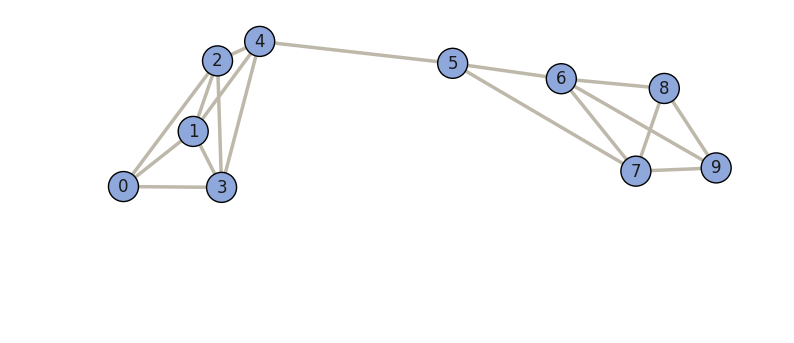

In [16]:
labels = [0] * N   # replace by one number per node, e.g. [0, 0, 1, 1, 0, ...]
show(labels)

## Group 3 · igraph
Type the code from your sheet into the cell below. The network is `graph`.

In [17]:
# type the code from your sheet

## Group 4 · graph-tool
Type the code from your sheet into the cell below. The first run installs graph-tool and takes one to three minutes.

In [23]:
def fit(g):
  state = gt.minimize_blockmodel_dl(g)
  return state.get_blocks().a.tolist()

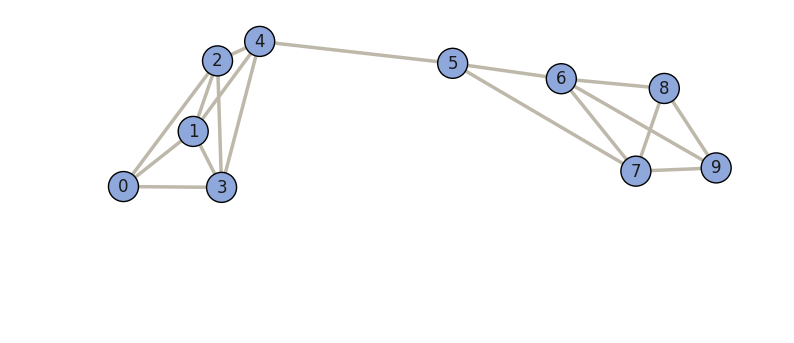

In [22]:
import os
# Force matplotlib in the subprocess to use the standard non-interactive Agg backend
os.environ["MPLBACKEND"] = "Agg"

labels = graph_tool(fit)
show(labels)

In [26]:
def fit_deg_corr(g):
    state = gt.minimize_blockmodel_dl(g, state_args=dict(deg_corr=True))
    return state.get_blocks().a.tolist()

In [38]:
labels = fit_deg_corr(fit)
show(labels)

NameError: name 'gt' is not defined

In [35]:
def fit_mcmc_arge(g):
    state = gt.minimize_blockmodel_dl(g, multilevel_mcmc_args=dict(B_min=1, B_max=2))
    return state.get_blocks().a.tolist()

In [37]:
labels = fit_mcmc_arge(fit)
show(labels)

NameError: name 'gt' is not defined

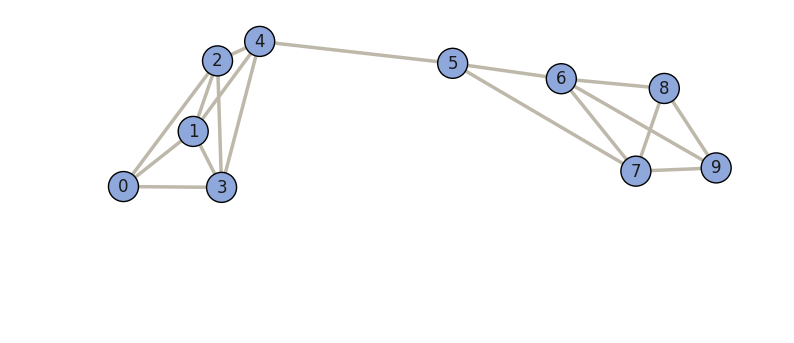

In [40]:
# 1. Define the function (inside, we use 'gt' and the passed graph 'g')
def fit_mcmc_correct(g):
    state = gt.minimize_blockmodel_dl(g, multilevel_mcmc_args=dict(B_min=1, B_max=2))
    return state.get_blocks().a.tolist()

# 2. Run the helper function and pass your function as an argument
labels = graph_tool(fit_mcmc_correct)

# 3. Visualize the output
show(labels)

### Demonstrating Variations Between SBM and Degree-Corrected SBM

To show a clear contrast for your presentation, we will construct a larger synthetic network (30 nodes) with three distinct communities and varying degrees. This will allow us to compare how **Standard SBM** and **Degree-Corrected SBM** group nodes differently.

## Mathematical Explanation: SBM vs. Degree-Corrected SBM

When presenting to the class, you can use these formulas to explain why the two algorithms partitioned your classroom seats differently.

### 1. Standard Stochastic Block Model (SBM)
In the standard SBM, we assume that the probability of an edge existing between node $i$ (in community $r$) and node $j$ (in community $s$) depends **only** on their community memberships.

Let $\theta_{rs}$ be the probability of connection between any node in group $r$ and group $s$. The probability of observing our adjacency matrix $A$ is modeled as:

$$P(A \mid z, \theta) = \prod_{i < j} \theta_{z_i, z_j}^{A_{ij}} (1 - \theta_{z_i, z_j})^{1 - A_{ij}}$$

Where:
* $z_i$ is the community label of node $i$.
* $\theta_{z_i, z_j}$ is the connection probability between the groups of node $i$ and node $j$.

**The Problem (Why Node 3 gets isolated):**
Because the probability $\theta_{rs}$ is completely uniform for all nodes inside a block, standard SBM expects **all nodes in the same community to have roughly similar degrees (number of connections)**. When Node 3 has a low degree compared to its neighbors, the model decides Node 3 cannot belong to the same block as the high-degree nodes, forcing it into a separate, isolated community.

---

### 2. Degree-Corrected Stochastic Block Model (DCSBM)
To fix this bias, the Degree-Corrected model introduces a parameters $k_i$ representing the individual degree propensity of each node $i$.

Under DCSBM, the expected number of edges between node $i$ and node $j$ is scaled directly by their individual degrees:

$$E[A_{ij}] = k_i k_j \theta_{z_i, z_j}$$

This changes the model likelihood to:

$$P(A \mid z, k, \theta) = \prod_{i < j} \left( k_i k_j \theta_{z_i, z_j} \right)^{A_{ij}} e^{-k_i k_j \theta_{z_i, z_j}}$$

**The Solution (Why the split is clean):**
By explicitly factoring out the individual degree propensity $k_i$, the model evaluates community membership based on **who** nodes connect to rather than **how many** connections they have. This is why Node 3 is correctly grouped with its actual neighbors in the orange community!

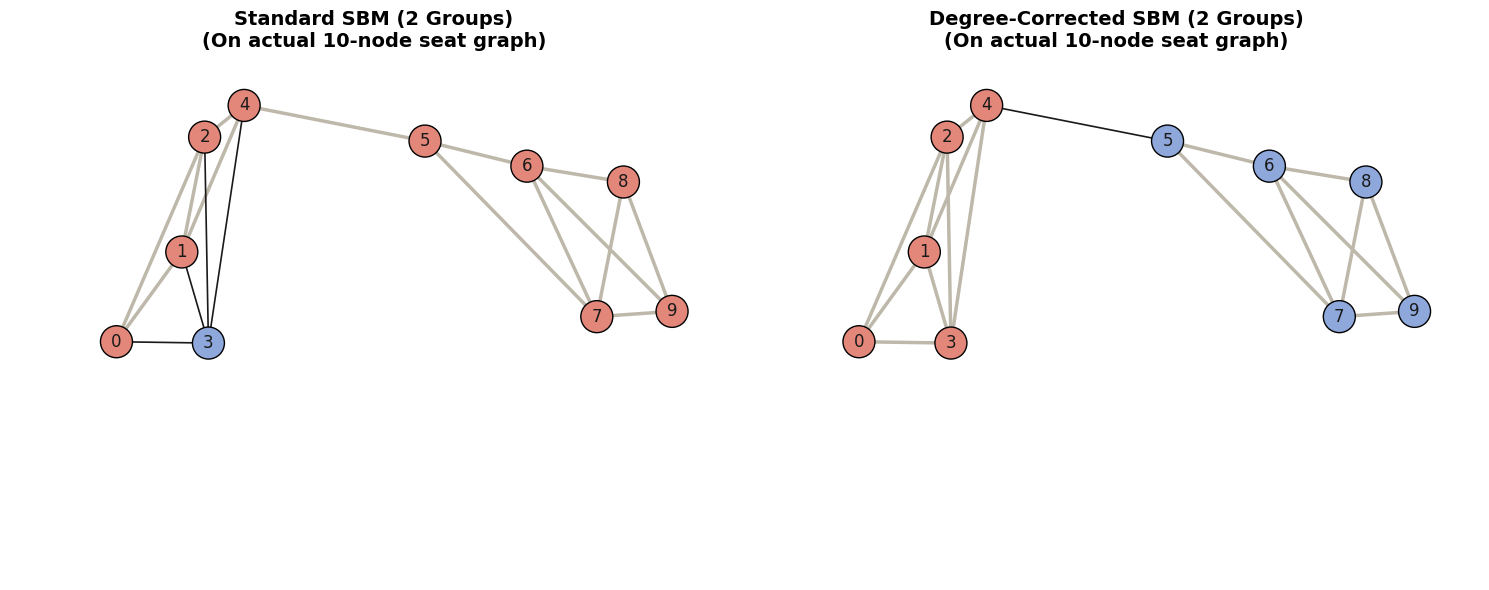

In [44]:
# 1. Define SBM fitting functions that find exactly 2 blocks (communities) on your actual data
def fit_standard(g):
    # Force standard SBM to find a 2-block partition by placing limits in multilevel_mcmc_args
    state = gt.minimize_blockmodel_dl(
        g,
        state_args=dict(deg_corr=False),
        multilevel_mcmc_args=dict(B_min=2, B_max=2)
    )
    return state.get_blocks().a.tolist()

def fit_corrected(g):
    # Force degree-corrected SBM to find a 2-block partition by placing limits in multilevel_mcmc_args
    state = gt.minimize_blockmodel_dl(
        g,
        state_args=dict(deg_corr=True),
        multilevel_mcmc_args=dict(B_min=2, B_max=2)
    )
    return state.get_blocks().a.tolist()

# 2. Run the partition models on your actual loaded 10-node graph
labels_standard = graph_tool(fit_standard)
labels_corrected = graph_tool(fit_corrected)

# 3. Plot the side-by-side comparison using your actual coordinates and layout
import igraph
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Function to map group labels to distinct colors from PALETTE
def get_colors(labels):
    unique_labels = np.unique(labels)
    return [PALETTE[int(np.where(unique_labels == g)[0][0]) % len(PALETTE)] for g in labels]

# Standard SBM Plot
col_std = get_colors(labels_standard)
cross_std = [labels_standard[u] != labels_standard[v] for u, v in graph.get_edgelist()]
igraph.plot(graph, target=ax1, layout=igraph.Layout(P.tolist()),
            vertex_color=col_std, vertex_size=32, vertex_label=list(range(N)),
            vertex_label_color="#1A1A1A",
            edge_color=["#1A1A1A" if c else "#BDB8AA" for c in cross_std],
            edge_width=[1.2 if c else 2.5 for c in cross_std])
ax1.set_title("Standard SBM (2 Groups)\n(On actual 10-node seat graph)", fontsize=14, fontweight='bold')

# Degree-Corrected SBM Plot
col_corr = get_colors(labels_corrected)
cross_corr = [labels_corrected[u] != labels_corrected[v] for u, v in graph.get_edgelist()]
igraph.plot(graph, target=ax2, layout=igraph.Layout(P.tolist()),
            vertex_color=col_corr, vertex_size=32, vertex_label=list(range(N)),
            vertex_label_color="#1A1A1A",
            edge_color=["#1A1A1A" if c else "#BDB8AA" for c in cross_corr],
            edge_width=[1.2 if c else 2.5 for c in cross_corr])
ax2.set_title("Degree-Corrected SBM (2 Groups)\n(On actual 10-node seat graph)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()